In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
X_train = joblib.load("../models/X_train.pkl")
X_test = joblib.load("../models/X_test.pkl")

y_train = joblib.load("../models/y_train.pkl")
y_test = joblib.load("../models/y_test.pkl")

preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

selector = joblib.load(
    "../models/feature_selector.pkl"
)

In [3]:
X_train_processed = preprocessor.transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [4]:
X_train_selected = selector.transform(
    X_train_processed
)

X_test_selected = selector.transform(
    X_test_processed
)

print(X_train_selected.shape)
print(X_test_selected.shape)

(4000, 15)
(1000, 15)


In [5]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=6,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=7
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}

In [6]:
print(y_train.unique())
print(y_test.unique())

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [7]:
y_train = y_train.map({
    "No": 0,
    "Yes": 1
})

y_test = y_test.map({
    "No": 0,
    "Yes": 1
})

In [8]:
results = []

trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(
        X_train_selected,
        y_train
    )

    y_pred = model.predict(
        X_test_selected
    )

    y_prob = model.predict_proba(
        X_test_selected
    )[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append({

        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc

    })

    trained_models[name] = model


Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training KNN...

Training SVM...


In [9]:
results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.877,0.629630,0.130769,0.216561,0.812697
2,Random Forest,0.867,0.457143,0.123077,0.193939,0.788709
1,Decision Tree,0.857,0.367347,0.138462,0.201117,0.772586
3,KNN,0.868,0.479167,0.176923,0.258427,0.718594
4,SVM,0.869,0.480000,0.092308,0.154839,0.697798


## Find the best model

In [10]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print(
    "Best Model:",
    best_model_name
)

Best Model: Logistic Regression


In [11]:
y_pred_best = best_model.predict(
    X_test_selected
)

y_prob_best = best_model.predict_proba(
    X_test_selected
)[:, 1]

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.88      0.99      0.93       870
       Churn       0.63      0.13      0.22       130

    accuracy                           0.88      1000
   macro avg       0.76      0.56      0.57      1000
weighted avg       0.85      0.88      0.84      1000



Confusion matrix

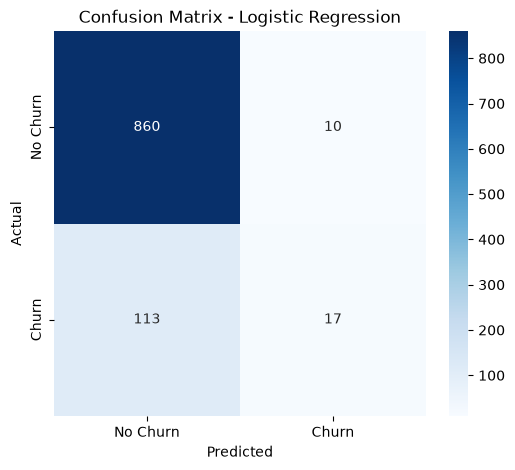

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Churn",
        "Churn"
    ],
    yticklabels=[
        "No Churn",
        "Churn"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

In [13]:
joblib.dump(
    best_model,
    "../models/churn_model.pkl"
)

print(
    f"{best_model_name} saved successfully."
)

Logistic Regression saved successfully.


In [14]:
model_metadata = {
    "model_name": best_model_name,
    "accuracy": float(
        accuracy_score(y_test, y_pred_best)
    ),
    "precision": float(
        precision_score(
            y_test,
            y_pred_best,
            zero_division=0
        )
    ),
    "recall": float(
        recall_score(
            y_test,
            y_pred_best,
            zero_division=0
        )
    ),
    "f1_score": float(
        f1_score(
            y_test,
            y_pred_best,
            zero_division=0
        )
    ),
    "roc_auc": float(
        roc_auc_score(
            y_test,
            y_prob_best
        )
    )
}

joblib.dump(
    model_metadata,
    "../models/model_metadata.pkl"
)

print(model_metadata)

{'model_name': 'Logistic Regression', 'accuracy': 0.877, 'precision': 0.6296296296296297, 'recall': 0.13076923076923078, 'f1_score': 0.21656050955414013, 'roc_auc': 0.8126967285587975}


In [15]:
import os

model_files = [
    "churn_model.pkl",
    "preprocessor.pkl",
    "feature_selector.pkl",
    "selected_features.pkl",
    "model_metadata.pkl"
]

for file in model_files:
    path = f"../models/{file}"

    print(
        f"{file}:",
        "✅ Found" if os.path.exists(path)
        else "❌ Missing"
    )

churn_model.pkl: ✅ Found
preprocessor.pkl: ✅ Found
feature_selector.pkl: ✅ Found
selected_features.pkl: ✅ Found
model_metadata.pkl: ✅ Found


In [16]:
import joblib

model = joblib.load(
    "../models/churn_model.pkl"
)

preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

selector = joblib.load(
    "../models/feature_selector.pkl"
)

metadata = joblib.load(
    "../models/model_metadata.pkl"
)

print("Model:", metadata["model_name"])
print("ROC-AUC:", metadata["roc_auc"])

Model: Logistic Regression
ROC-AUC: 0.8126967285587975


In [17]:
sample_customer = X_test.iloc[[0]]

print(sample_customer)

     Gender  SeniorCitizen Partner Dependents  Tenure PhoneService  \
3081   Male              0     Yes        Yes      41          Yes   

     MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
3081           Yes     Fiber optic             No           No  ...   

     TotalCharges AverageMonthlySpend ChargeDifference ServiceCount  \
3081      3147.52            76.76878          0.54122            3   

      TenureGroup ChargeGroup ContractRisk  ElectronicPayment  HasTechSupport  \
3081  Established        High            2                  1               0   

      HasOnlineSecurity  
3081                  0  

[1 rows x 28 columns]


In [18]:
sample_processed = preprocessor.transform(
    sample_customer
)

In [19]:
sample_selected = selector.transform(
    sample_processed
)

In [20]:
prediction = model.predict(
    sample_selected
)[0]

probability = model.predict_proba(
    sample_selected
)[0][1]

print("Prediction:", prediction)
print(
    "Churn Probability:",
    round(probability * 100, 2),
    "%"
)

Prediction: 0
Churn Probability: 15.99 %


In [21]:
if prediction == 1:
    print("⚠️ Customer is likely to churn.")
else:
    print("✅ Customer is unlikely to churn.")

✅ Customer is unlikely to churn.
